In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import glob as glob
from matplotlib.ticker import LogLocator, FuncFormatter
from matplotlib.ticker import MaxNLocator
from matplotlib.patches import Patch
import matplotlib as mpl
from matplotlib.lines import Line2D

from scipy.stats import mannwhitneyu

In [2]:
# Read in the files from the classifier which was produced in the middle of 2025
files = pd.read_csv('../data/Radius_100_patient_id_edited.csv')

In [3]:
# Add clinical information to the dataframe
outcomes = pd.read_excel('../data/Outcomes_master_simplified_updatedJan24_patient_updated.xlsx')
outcomes['Outcome_C6_revised_Vid'] = outcomes['Outcome_C6_revised_Vid'].replace('non-responder_2', 'Non-responder').replace('responder_1', 'Responder')
outcomes['Outcome_C12_CC486'] = outcomes['Outcome_C12_CC486'].replace('non-responder_2', 'Non-responder').replace('responder_1', 'Responder')

outcomes_6 = dict(zip(outcomes['PID'], outcomes['Outcome_C6_revised_Vid']))
outcomes_12 = dict(zip(outcomes['PID'], outcomes['Outcome_C12_CC486']))
diagnosis = dict(zip(outcomes['PID'], outcomes['Diagnosis']))

files['diagnosis'] = files['PID'].map(diagnosis)
files['outcomes_6'] = files['PID'].map(outcomes_6)
files['outcomes_12'] = files['PID'].map(outcomes_12)

In [4]:
# Delete the patient P02 as it has few cells. This patient was included in the clustering
files = files.loc[files['PID'] != 'P02', :]

In [5]:
# Create dictionaries which describe the number of trephines with cells in the cluster and another
# dictionary with the number of patients with a cell in the cluster
sample_dict = {}
patient_dict = {}
cell_num_dict = {}

for i in range(59): # use range 45 to exclude the smaller clusters
    a = files.loc[files['Leiden_Group'] == i, :]
    print(i, a.shape)
    print(len(a['pid_tp'].value_counts()))
    cell_num_dict[i] = a.shape[0]
    sample_dict[i] = len(a['pid_tp'].value_counts())
    patient_dict[i] = len(a['PID'].value_counts())
    print('\n')

0 (35918, 19)
30


1 (33479, 19)
26


2 (33178, 19)
32


3 (33048, 19)
9


4 (32493, 19)
32


5 (30499, 19)
32


6 (30313, 19)
32


7 (29350, 19)
30


8 (28467, 19)
31


9 (28291, 19)
32


10 (27874, 19)
32


11 (27452, 19)
32


12 (27164, 19)
31


13 (26512, 19)
32


14 (26432, 19)
32


15 (26406, 19)
31


16 (26348, 19)
32


17 (25992, 19)
32


18 (25770, 19)
32


19 (25189, 19)
32


20 (24877, 19)
31


21 (24078, 19)
31


22 (23661, 19)
32


23 (23138, 19)
23


24 (23100, 19)
14


25 (22581, 19)
32


26 (22131, 19)
28


27 (22122, 19)
17


28 (20764, 19)
31


29 (19770, 19)
32


30 (19525, 19)
32


31 (19532, 19)
32


32 (19520, 19)
22


33 (18075, 19)
32


34 (17978, 19)
32


35 (17857, 19)
17


36 (17830, 19)
11


37 (16630, 19)
31


38 (15833, 19)
31


39 (14163, 19)
32


40 (13640, 19)
28


41 (12483, 19)
13


42 (11638, 19)
32


43 (10343, 19)
6


44 (10331, 19)
24


45 (848, 19)
7


46 (743, 19)
28


47 (329, 19)
25


48 (251, 19)
2


49 (231, 19)
20


50 (224, 19)
9


51 (185

In [6]:
cell_num_dict

{0: 35918,
 1: 33479,
 2: 33178,
 3: 33048,
 4: 32493,
 5: 30499,
 6: 30313,
 7: 29350,
 8: 28467,
 9: 28291,
 10: 27874,
 11: 27452,
 12: 27164,
 13: 26512,
 14: 26432,
 15: 26406,
 16: 26348,
 17: 25992,
 18: 25770,
 19: 25189,
 20: 24877,
 21: 24078,
 22: 23661,
 23: 23138,
 24: 23100,
 25: 22581,
 26: 22131,
 27: 22122,
 28: 20764,
 29: 19770,
 30: 19525,
 31: 19532,
 32: 19520,
 33: 18075,
 34: 17978,
 35: 17857,
 36: 17830,
 37: 16630,
 38: 15833,
 39: 14163,
 40: 13640,
 41: 12483,
 42: 11638,
 43: 10343,
 44: 10331,
 45: 848,
 46: 743,
 47: 329,
 48: 251,
 49: 231,
 50: 224,
 51: 185,
 52: 170,
 53: 154,
 54: 149,
 55: 137,
 56: 109,
 57: 109,
 58: 104}

In [7]:
# Calculate the shannon diversity for each cluster

# Get all unique trephines (should be 32)
all_patients = files['pid_tp'].unique()

# Count by cluster and alias
x = files.groupby(['Leiden_Group', 'pid_tp']).size().reset_index(name='Count')


x = x.loc[x['Leiden_Group'] <= 58, :] # Filter out the smaller clusters

# Calculate Shannon diversity for each cluster
shannon_diversity = {}

for cluster in x['Leiden_Group'].unique():
    cluster_data = x.loc[x['Leiden_Group'] == cluster, :].copy()
    
    # Find missing patients for this cluster
    present_patients = cluster_data['pid_tp'].values
    missing_patients = [p for p in all_patients if p not in present_patients]
    
    # Add missing patients with count = 0
    if len(missing_patients) > 0:
        missing_df = pd.DataFrame({'pid_tp': missing_patients, 'Count': 1}, index=range(len(missing_patients)))
        
        cluster_data = pd.concat([cluster_data, missing_df], ignore_index=True)
    
    # Now cluster_data should have 32 rows
    print(f"Cluster {cluster}: {len(cluster_data)} patients")
    
    # Calculate proportions (excluding zeros for Shannon calculation)
    total = cluster_data['Count'].sum()
    proportions = cluster_data.loc[cluster_data['Count'] > -1, 'Count'] / total
   
    # Shannon diversity: H = -Σ(p_i * ln(p_i))
    shannon = -np.sum(proportions * np.log(proportions))
    
    shannon_diversity[cluster] = shannon
    print(f"Cluster {cluster}: Shannon diversity = {shannon:.3f}")

Cluster 0: 32 patients
Cluster 0: Shannon diversity = 2.723
Cluster 1: 32 patients
Cluster 1: Shannon diversity = 0.975
Cluster 2: 32 patients
Cluster 2: Shannon diversity = 2.879
Cluster 3: 32 patients
Cluster 3: Shannon diversity = 0.706
Cluster 4: 32 patients
Cluster 4: Shannon diversity = 2.953
Cluster 5: 32 patients
Cluster 5: Shannon diversity = 2.840
Cluster 6: 32 patients
Cluster 6: Shannon diversity = 2.709
Cluster 7: 32 patients
Cluster 7: Shannon diversity = 1.865
Cluster 8: 32 patients
Cluster 8: Shannon diversity = 2.804
Cluster 9: 32 patients
Cluster 9: Shannon diversity = 2.840
Cluster 10: 32 patients
Cluster 10: Shannon diversity = 2.931
Cluster 11: 32 patients
Cluster 11: Shannon diversity = 3.029
Cluster 12: 32 patients
Cluster 12: Shannon diversity = 2.487
Cluster 13: 32 patients
Cluster 13: Shannon diversity = 2.943
Cluster 14: 32 patients
Cluster 14: Shannon diversity = 1.810
Cluster 15: 32 patients
Cluster 15: Shannon diversity = 1.857
Cluster 16: 32 patients
Clus

In [8]:
# Read in a df which maps a cluster to a cell type (i.e. dominant focal cell type of each cell type)
cluster_cell = pd.read_excel('../data/2026_03_10_all_clusters_annotated.xlsx')#2026_03_02_Cluster_to_celltype.xlsx')
cluster_cell_dict = dict(zip(cluster_cell['Cluster'], cluster_cell['Cell_Type']))
cluster_cell_dict

# Create a dictionary to match each focal cell type to a color
color = pd.read_excel('../data/cell_type_colors.xlsx', sheet_name= '2026_02_23')

new_row = pd.DataFrame({'Cell_Type': ['Endo'], 'Color': ['#FFD94AFF']})
color = pd.concat([color, new_row], ignore_index=True)

color_dict = dict(zip(color['Cell_Type'], color['Color']))
color_dict

{'HSPC': '#3CB7CCFF',
 'Stromal': '#32A251FF',
 'Endothelial': '#FFD94AFF',
 'CD8_T': '#FF7F0FFF',
 'CD4_T': '#B85A0DFF',
 'Mixed': 'Grey',
 'Endo': '#FFD94AFF'}

In [9]:
# # Make a scatter plot of trephine number versus shannon diversity

# clusters = list(shannon_diversity.keys())

# x_vals = [sample_dict[c] for c in clusters]
# y_vals = [shannon_diversity[c] for c in clusters]
# edge_colors = [color_dict[cluster_cell_dict[c]] for c in clusters]

# size_list = [size/500 for size in cell_num_dict.values()]



# fig, ax = plt.subplots(figsize = (2, 2))
# ax.scatter(x = sample_dict.values(), y = shannon_diversity.values(), s = size_list, lw =0.5, color = 'white',
#            edgecolor = edge_colors)

# for cluster, x, y in zip(shannon_diversity.keys(), sample_dict.values(), shannon_diversity.values()):
#     if (y <= 1) or (x <= 10):
#         ax.annotate(str(cluster), (x, y), textcoords="offset points", xytext=(1, 1), fontsize=8)


# ax.set_xlim(0, 35)
# ax.set_ylim(0, 3.2)
# ax.spines[['top', 'right']].set_visible(False)
# ax.tick_params(pad = 1, length = 1, labelsize = 7)
# ax.axvline(8, color = 'black', lw = 0.5)

# ax.set_ylabel('Shannon diversity of\nsample contribution to cluster', fontsize = 7)
# ax.set_xlabel('# of samples with a cell in cluster', fontsize = 7)

# legend_sizes = [4, 200, 80]  # choose values that span your actual data range

# legend_elements = [
#     Line2D([0], [0], marker='o', color='w', markerfacecolor='white',
#            markeredgecolor='black', markeredgewidth=0.5,
#            markersize=(s/500)**0.5 * 2,  # sqrt scaling: matplotlib 's' is area, not diameter
#            label=f'{s} cells')
#     for s in legend_sizes
# ]

# ax.legend(handles=legend_elements, loc='upper right', fontsize=6,
#           title='Cells per cluster', title_fontsize=6,
#           frameon=False, labelspacing=1.2, handletextpad=1)


# plt.tight_layout()
# fig.savefig('../results/scatterplot_with_all_clusters.pdf', dpi = 600)

In [10]:
cluster_color = pd.read_csv('../data/color_of_all_cells_umap.csv', index_col = 0)
cluster_color_dict = dict(zip(cluster_color['cluster'], cluster_color['color']))
cluster_color_dict

{0: '#1f77b4',
 1: '#aec7e8',
 2: '#ff7f0e',
 3: '#ffbb78',
 4: '#2ca02c',
 5: '#98df8a',
 6: '#d62728',
 7: '#ff9896',
 8: '#9467bd',
 9: '#c5b0d5',
 10: '#8c564b',
 11: '#c49c94',
 12: '#e377c2',
 13: '#f7b6d2',
 14: '#7f7f7f',
 15: '#c7c7c7',
 16: '#bcbd22',
 17: '#dbdb8d',
 18: '#17becf',
 19: '#9edae5',
 20: '#393b79',
 21: '#5254a3',
 22: '#6b6ecf',
 23: '#9c9ede',
 24: '#637939',
 25: '#8ca252',
 26: '#b5cf6b',
 27: '#cedb9c',
 28: '#8c6d31',
 29: '#bd9e39',
 30: '#e7ba52',
 31: '#e7cb94',
 32: '#843c39',
 33: '#ad494a',
 34: '#d6616b',
 35: '#e7969c',
 36: '#7b4173',
 37: '#a55194',
 38: '#ce6dbd',
 39: '#de9ed6',
 40: '#3182bd',
 41: '#6baed6',
 42: '#9ecae1',
 43: '#c6dbef',
 44: '#e6550d',
 45: '#fd8d3c',
 46: '#fdae6b',
 47: '#fdd0a2',
 48: '#31a354',
 49: '#a1d99b',
 50: '#c7e9c0',
 51: '#756bb1',
 52: '#9e9ac8',
 53: '#bcbddc',
 54: '#dadaeb',
 55: '#636363',
 56: '#969696',
 57: '#bdbdbd',
 58: '#d9d9d9'}

In [11]:
cluster_cell_dict

{0: 'CD4_T',
 1: 'HSPC',
 2: 'HSPC',
 3: 'HSPC',
 4: 'Mixed',
 5: 'Mixed',
 6: 'HSPC',
 7: 'HSPC',
 8: 'Stromal',
 9: 'Mixed',
 10: 'HSPC',
 11: 'Endo',
 12: 'CD8_T',
 13: 'CD8_T',
 14: 'HSPC',
 15: 'HSPC',
 16: 'HSPC',
 17: 'CD8_T',
 18: 'CD8_T',
 19: 'HSPC',
 20: 'CD4_T',
 21: 'HSPC',
 22: 'HSPC',
 23: 'HSPC',
 24: 'HSPC',
 25: 'Mixed',
 26: 'HSPC',
 27: 'CD4_T',
 28: 'HSPC',
 29: 'Mixed',
 30: 'Stromal',
 31: 'Mixed',
 32: 'Stromal',
 33: 'CD8_T',
 34: 'Endo',
 35: 'HSPC',
 36: 'Stromal',
 37: 'HSPC',
 38: 'Stromal',
 39: 'CD8_T',
 40: 'Stromal',
 41: 'CD4_T',
 42: 'CD8_T',
 43: 'CD4_T',
 44: 'CD8_T',
 45: 'Endo',
 46: 'CD8_T',
 47: 'CD4_T',
 48: 'Stromal',
 49: 'HSPC',
 50: 'CD8_T',
 51: 'HSPC',
 52: 'Endo',
 53: 'HSPC',
 54: 'HSPC',
 55: 'Stromal',
 56: 'CD8_T',
 57: 'Stromal',
 58: 'CD4_T'}

45
46
47
48
49
50
51
52
53
54
55
56
57
58


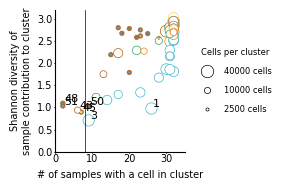

In [12]:
# Make a scatter plot of trephine number versus shannon diversity colored by the focal cell type
clusters = list(shannon_diversity.keys())
x_vals = [sample_dict[c] for c in clusters]
y_vals = [shannon_diversity[c] for c in clusters]
edge_colors = [color_dict[cluster_cell_dict[c]] for c in clusters]
size_list = [cell_num_dict[c] / 500 for c in clusters]  # fixed to match cluster order

fig, ax = plt.subplots(figsize=(3, 2))

for cluster, x, y in zip(clusters, x_vals, y_vals): # Add a grey dot to indicate the small clusters 
    if cluster >= 45:
        ax.scatter(x = x_vals[cluster], y=y_vals[cluster], s=10, lw=0.5, color='grey', edgecolor=edge_colors)
        print(cluster)
        
ax.scatter(x=x_vals, y=y_vals, s=size_list, lw=0.5, color='white', edgecolor=edge_colors)
for cluster, x, y in zip(clusters, x_vals, y_vals): # Add text to label the graphs. Also add 
    if (y <= 1) or (x <= 10):
        ax.annotate(str(cluster), (x, y), textcoords="offset points", xytext=(1, 1), fontsize=8)


ax.set_xlim(0, 35)
ax.set_ylim(0, 3.2)
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(pad=1, length=1, labelsize=7)
ax.axvline(8, color='black', lw=0.5)
ax.set_ylabel('Shannon diversity of\nsample contribution to cluster', fontsize=7)
ax.set_xlabel('# of samples with a cell in cluster', fontsize=7)

legend_sizes = [40000, 10000, 2500]  # raw cell counts, same units as cell_num_dict
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='white',
           markeredgecolor='black', markeredgewidth=0.5,
           markersize=(s/500)**0.5,  #scatter()'s s parameter = marker area, in points², #Line2D's markersize = marker diameter, in points
           label=f'{s} cells')
    for s in legend_sizes
]

ax.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1.05, 0.5),
          fontsize=6, title='Cells per cluster', title_fontsize=6,
          frameon=False, labelspacing=1.2, handletextpad=1)

plt.tight_layout()
fig.savefig('../results/scatterplot_with_all_clusters_by_celltype.pdf', dpi=600, bbox_inches='tight')

45
46
47
48
49
50
51
52
53
54
55
56
57
58


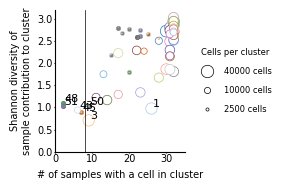

In [13]:
# Make a scatter plot of trephine number versus shannon diversity colored by the focal cell type 
clusters = list(shannon_diversity.keys())
x_vals = [sample_dict[c] for c in clusters]
y_vals = [shannon_diversity[c] for c in clusters]
edge_colors = [cluster_color_dict[c] for c in clusters]
size_list = [cell_num_dict[c] / 500 for c in clusters]

fig, ax = plt.subplots(figsize=(3, 2))

for cluster, x, y in zip(clusters, x_vals, y_vals): # Add a grey dot to all cells
    if cluster >= 45:
        ax.scatter(x=x, y=y, s=10, lw=0.5, color='grey', edgecolor=cluster_color_dict[cluster])
        print(cluster)
        

ax.scatter(x=x_vals, y=y_vals, s=size_list, lw=0.5, color='white', edgecolor=edge_colors)
for cluster, x, y in zip(clusters, x_vals, y_vals): # Add text to label the graphs. Also add 
    if (y <= 1) or (x <= 10):
        ax.annotate(str(cluster), (x, y), textcoords="offset points", xytext=(1, 1), fontsize=8)


ax.set_xlim(0, 35)
ax.set_ylim(0, 3.2)
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(pad=1, length=1, labelsize=7)
ax.axvline(8, color='black', lw=0.5)
ax.set_ylabel('Shannon diversity of\nsample contribution to cluster', fontsize=7)
ax.set_xlabel('# of samples with a cell in cluster', fontsize=7)

legend_sizes = [40000, 10000, 2500]  # raw cell counts, same units as cell_num_dict
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='white',
           markeredgecolor='black', markeredgewidth=0.5,
           markersize=(s/500)**0.5,  #scatter()'s s parameter = marker area, in points², #Line2D's markersize = marker diameter, in points
           label=f'{s} cells')
    for s in legend_sizes
]

ax.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1.05, 0.5),
          fontsize=6, title='Cells per cluster', title_fontsize=6,
          frameon=False, labelspacing=1.2, handletextpad=1)

plt.tight_layout()
fig.savefig('../results/scatterplot_with_all_clusters_by_clustertype.pdf', dpi=600, bbox_inches='tight')

In [14]:
# Filter the clusters for larger clusters
sample_dict = {k: v for k, v in sample_dict.items() if k <= 44}
shannon_diversity = {k: v for k, v in shannon_diversity.items() if k <= 44}

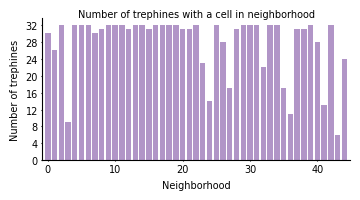

In [15]:
# Make a figure which shows the number of samples with a cell in that neighborhood
# Note that many patients have multiple trephines (each trephine will be included multiple times)

plt.rcParams['pdf.fonttype'] = 42

# Create figure and axis
fig, ax = plt.subplots(figsize=(3.7, 2.1))

# Create bar chart
ax.bar(sample_dict.keys(), sample_dict.values(), color = '#652d90', alpha = 0.5)
ax.set_xlabel('Neighborhood', fontsize = 7)
ax.set_ylabel('Number of trephines', fontsize = 7)
ax.set_title('Number of trephines with a cell in neighborhood', fontsize = 7, y = 0.95)
ax.tick_params(labelsize = 7, pad = 2, length = 1)
ax.spines[['top', 'right']].set_visible(False)
# Reduce space between y-axis and first bar
ax.margins(x=0.01) 

# Force integer y-axis labels
ax.yaxis.set_major_locator(MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig('../results/number_of_trephine_per_cluster.pdf')
plt.show()

In [16]:
proportions

0     0.059322
1     0.008475
2     0.008475
3     0.025424
4     0.016949
5     0.288136
6     0.016949
7     0.033898
8     0.016949
9     0.008475
10    0.076271
11    0.008475
12    0.161017
13    0.033898
14    0.033898
15    0.008475
16    0.025424
17    0.050847
18    0.008475
19    0.008475
20    0.008475
21    0.008475
22    0.008475
23    0.008475
24    0.008475
25    0.008475
26    0.008475
27    0.008475
28    0.008475
29    0.008475
30    0.008475
31    0.008475
Name: Count, dtype: float64

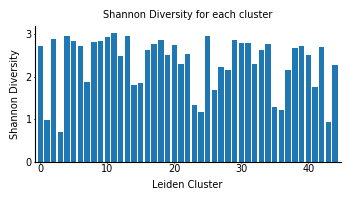

In [17]:
# If shannon_diversity is a dictionary
clusters = list(shannon_diversity.keys())
diversity_values = list(shannon_diversity.values())

fig, ax = plt.subplots(figsize=(3.7, 2.1))
ax.bar(clusters, diversity_values)
ax.set_xlabel('Leiden Cluster', fontsize = 7)
ax.set_ylabel('Shannon Diversity', fontsize = 7)
ax.set_title('Shannon Diversity for each cluster', fontsize = 7)
ax.tick_params(pad = 1, length = 1, labelsize = 7)
ax.spines[['top', 'right']].set_visible(False)
ax.margins(x=0.01)
plt.tight_layout()
fig.savefig('../results/shannon_diversity_across_trephines.pdf')

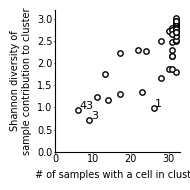

In [18]:
# Make a scatter plot of trephine number versus shannon diversity

fig, ax = plt.subplots(figsize = (2, 2))
ax.scatter(x = sample_dict.values(), y = shannon_diversity.values(), s = 15, lw =1, color = 'white',
           edgecolor = 'black')

for cluster, x, y in zip(shannon_diversity.keys(), sample_dict.values(), shannon_diversity.values()):
    if (y <= 1) or (x <= 10):
        ax.annotate(str(cluster), (x, y), textcoords="offset points", xytext=(1, 1), fontsize=8)


ax.set_xlim(0, 33)
ax.set_ylim(0, 3.2)
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(pad = 1, length = 1, labelsize = 7)

ax.set_ylabel('Shannon diversity of\nsample contribution to cluster', fontsize = 7)
ax.set_xlabel('# of samples with a cell in cluster', fontsize = 7)

plt.tight_layout()
fig.savefig('../results/scatterplot.pdf')

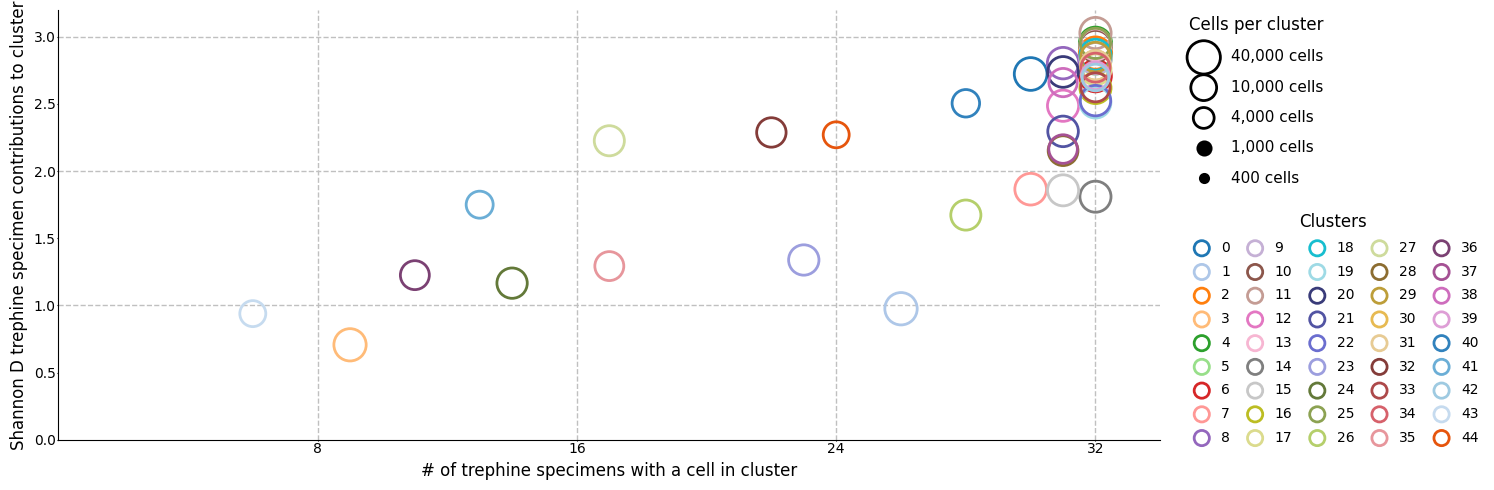

In [20]:
plot_data = pd.DataFrame([sample_dict], index=[0]).T.reset_index()
plot_data.columns = ['cluster','contrib_treph']
plot_data['shannon'] = plot_data['cluster'].replace(shannon_diversity)
plot_data['cluster_color'] = plot_data['cluster'].replace(cluster_color_dict)
plot_data['cluster_size'] = plot_data['cluster'].replace(cell_num_dict)
#create scaled marker sizes
log_size = np.log10(plot_data['cluster_size'])
# Scale to marker diameters (e.g. 4–20 pt)
 
SIZE_MIN = 400
SIZE_MAX = 40000
 
DIAM_MIN = 6
DIAM_MAX = 24
 
 
plot_data["marker_diameter"] = np.interp(
    np.log10(plot_data["cluster_size"]),
    (np.log10(SIZE_MIN), np.log10(SIZE_MAX)),
    (DIAM_MIN, DIAM_MAX)
)
 
# Convert diameter to scatter area (points²)
plot_data["marker_size"] = plot_data["marker_diameter"]**2
 
 
fig, ax = plt.subplots(figsize=(15, 5))
 
plot_data_small = plot_data.loc[plot_data['cluster_size'] <= 1000]
plot_data_large = plot_data.loc[plot_data['cluster_size'] > 1000]
 
# Large dots
ax.scatter(
    plot_data_large["contrib_treph"],
    plot_data_large["shannon"],
    s=plot_data_large["marker_size"],
    edgecolor=plot_data_large['cluster_color'],
    lw=2,
    facecolors='none',
    zorder=10
)
 
# Small dots
ax.scatter(
    plot_data_small["contrib_treph"],
    plot_data_small["shannon"],
    s=plot_data_small["marker_size"],
    edgecolor=plot_data_small['cluster_color'],
    lw=2,
    c=plot_data_small['cluster_color'],
    zorder=1
)
 
ax.set_xlim(0, 34)
ax.set_xticks([8,16,24,32])
ax.set_ylim(0, 3.2)
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(pad=1, length=1, labelsize=10)
for v in [8,16,24,32]:
    ax.axvline(v, color='silver', lw=1, linestyle='--', zorder=0)
for h in [1,2,3]:
    ax.axhline(h, color='silver', lw=1, linestyle='--', zorder=0)
ax.set_ylabel('Shannon D trephine specimen contributions to cluster', fontsize=12)
ax.set_xlabel('# of trephine specimens with a cell in cluster', fontsize=12)
 
# -----------------------
# Size legend
# -----------------------
legend_values = np.array([40000, 10000, 4000, 1000, 400])
 
legend_diameters = np.interp(
    np.log10(legend_values),
    (np.log10(SIZE_MIN), np.log10(SIZE_MAX)),
    (DIAM_MIN, DIAM_MAX)
)
 
legend_sizes = legend_diameters**2
 
size_handles = []
for v, s in zip(legend_values, legend_sizes):
    filled = v <= 1000  # fill the two smallest entries
    size_handles.append(
        ax.scatter(
            [], [],
            s=s,
            marker='o',
            facecolors='black' if filled else 'none',
            edgecolors='black',
            linewidths=2
        )
    )
 
size_legend = ax.legend(
    handles=size_handles,
    labels=[f'{v:,} cells' for v in legend_values],
    loc='upper left',
    bbox_to_anchor=(1.02, 1.00),
    fontsize=11,
    title='Cells per cluster',
    title_fontsize=12,
    frameon=False,
    labelspacing=1.0,
    handletextpad=0.8,
    borderaxespad=0.0
)
ax.add_artist(size_legend)
 
# -----------------------
# Color / cluster legend
# -----------------------
cluster_lookup = (
    plot_data[['cluster', 'cluster_color', 'cluster_size']]
    .drop_duplicates(subset='cluster')
    .sort_values('cluster')
)
 
color_handles = []
color_labels = []
 
for _, row in cluster_lookup.iterrows():
    open_circle = row['cluster_size'] > 1000
 
    color_handles.append(
        ax.scatter(
            [], [],
            s=120,
            marker='o',
            facecolors='none' if open_circle else row['cluster_color'],
            edgecolors=row['cluster_color'],
            linewidths=2
        )
    )
    color_labels.append(f"{int(row['cluster'])}")
 
ncols = int(np.ceil(len(color_handles) / 10))  # 10 rows, wrap into columns
 
color_legend = ax.legend(
    handles=color_handles,
    labels=color_labels,
    loc='upper left',
    bbox_to_anchor=(1.02, 0.54),
    ncol=ncols,
    fontsize=10,
    title='Clusters',
    title_fontsize=12,
    frameon=False,
    labelspacing=0.7,
    handletextpad=0.4,
    columnspacing=0.8,
    borderaxespad=0.0
)
 
# Reserve space on the right for both legends
fig.subplots_adjust(right=0.72)
fig.tight_layout()
 
# plt.show()
fig.savefig('../results/Scatter_shannon_trephine_clustersize_v1.pdf',bbox_inches='tight', format = 'pdf', dpi = 600)